# Hotel Booking Cancellation Prediction


## Setup and Data Cleaning Utilities


In [1]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split


DATA_CANDIDATES = [Path("data/raw/hotel_bookings.csv"), Path("data/hotel_bookings.csv")]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
LEAKAGE_COLUMNS = [
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
]


def load_raw_data():
    return pd.read_csv(DATA_PATH)


def clean_booking_data(df):
    cleaned_df = df.copy()
    cleaned_df["children"] = cleaned_df["children"].fillna(0).astype(int)
    cleaned_df["country"] = cleaned_df["country"].fillna("Unknown")
    cleaned_df["agent"] = (
        cleaned_df["agent"].astype("Int64").astype("string").fillna("No agent")
    )
    cleaned_df["company"] = (
        cleaned_df["company"].astype("Int64").astype("string").fillna("No company")
    )

    cleaned_df["total_guests"] = (
        cleaned_df["adults"] + cleaned_df["children"] + cleaned_df["babies"]
    )
    cleaned_df["total_stays"] = (
        cleaned_df["stays_in_weekend_nights"] + cleaned_df["stays_in_week_nights"]
    )
    cleaned_df["is_family"] = (
        (cleaned_df["children"] > 0) | (cleaned_df["babies"] > 0)
    ).astype(int)

    cleaned_df = cleaned_df[
        (cleaned_df["total_guests"] > 0)
        & (cleaned_df["total_stays"] > 0)
        & (cleaned_df["adr"] >= 0)
    ].copy()
    return cleaned_df.drop(columns=LEAKAGE_COLUMNS)


def load_cleaned_data():
    return clean_booking_data(load_raw_data())


def take_stratified_sample(df, sample_size, random_state=42):
    if sample_size is None or sample_size >= len(df):
        return df.copy()
    sample, _ = train_test_split(
        df,
        train_size=sample_size,
        stratify=df["is_canceled"],
        random_state=random_state,
    )
    return sample.copy()


## 1. Exploratory Data Analysis

Dataset shape: (119390, 32)

Numerical summary
                              count    mean     std   min    25%    50%  \
lead_time                  119390.0  104.01  106.86  0.00  18.00  69.00   
adr                        119390.0  101.83   50.54 -6.38  69.29  94.58   
stays_in_weekend_nights    119390.0    0.93    1.00  0.00   0.00   1.00   
stays_in_week_nights       119390.0    2.50    1.91  0.00   1.00   2.00   
adults                     119390.0    1.86    0.58  0.00   2.00   2.00   
children                   119386.0    0.10    0.40  0.00   0.00   0.00   
babies                     119390.0    0.01    0.10  0.00   0.00   0.00   
booking_changes            119390.0    0.22    0.65  0.00   0.00   0.00   
total_of_special_requests  119390.0    0.57    0.79  0.00   0.00   0.00   

                             75%     max  
lead_time                  160.0   737.0  
adr                        126.0  5400.0  
stays_in_weekend_nights      2.0    19.0  
stays_in_week_nights         3

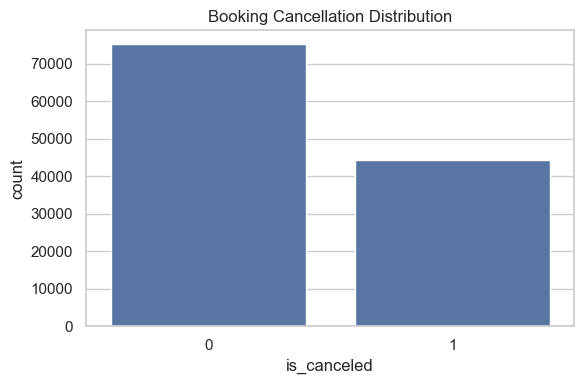

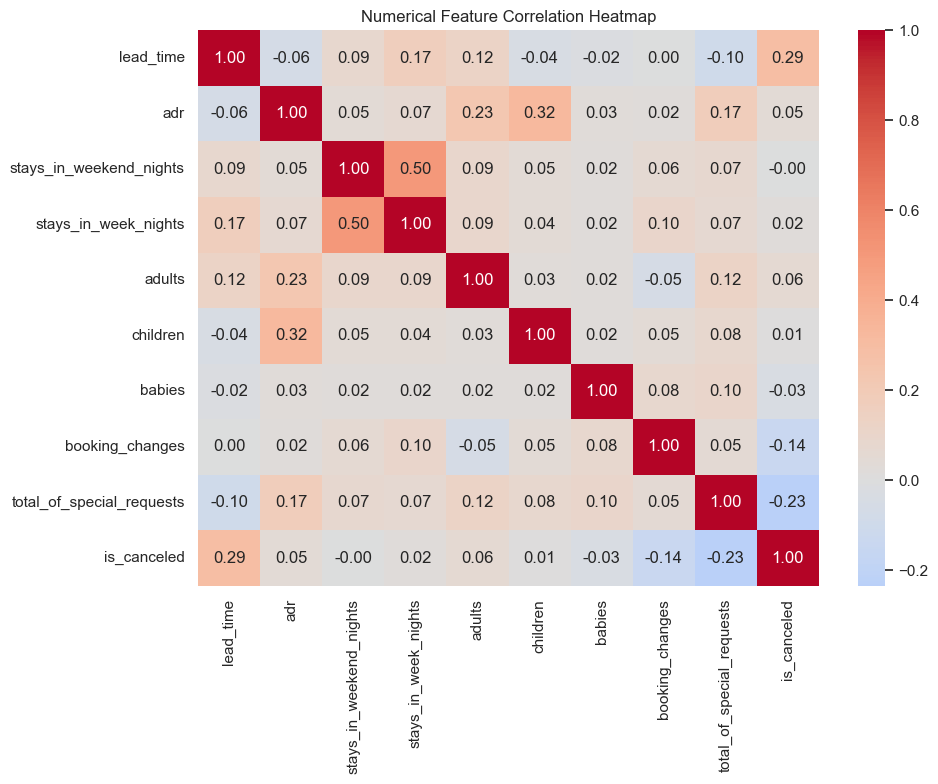

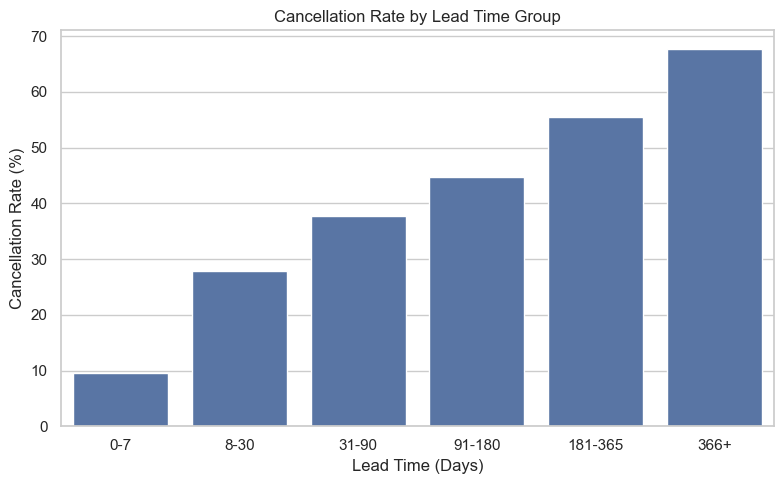

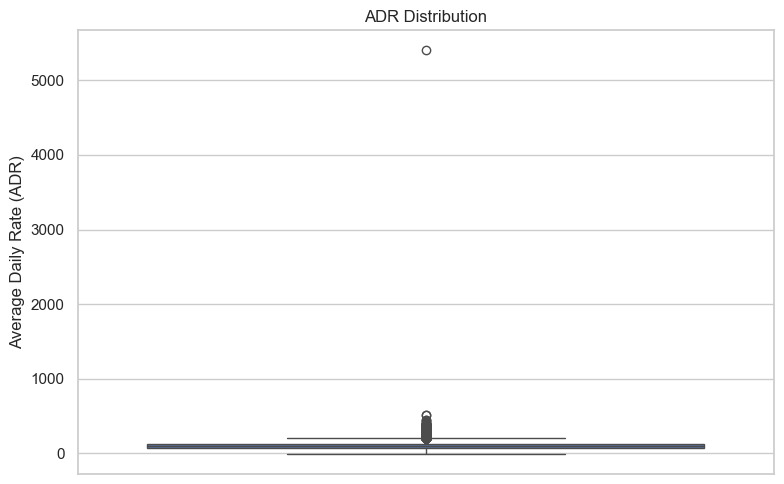

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = load_raw_data()

numerical_columns = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "booking_changes",
    "total_of_special_requests",
]
rate_columns = ["hotel", "deposit_type", "customer_type", "market_segment"]

print("Dataset shape:", df.shape)
print("\nNumerical summary")
print(df[numerical_columns].describe().T.round(2))

print("\nMissing values")
print(df.isnull().sum().loc[lambda values: values > 0].sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

total_guests = df["adults"] + df["children"].fillna(0) + df["babies"]
total_stays = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
print("Zero total guests:", (total_guests == 0).sum())
print("Zero total stay nights:", (total_stays == 0).sum())
print("Negative ADR:", (df["adr"] < 0).sum())

q1 = df["adr"].quantile(0.25)
q3 = df["adr"].quantile(0.75)
iqr = q3 - q1
adr_outliers = df[(df["adr"] < q1 - 1.5 * iqr) | (df["adr"] > q3 + 1.5 * iqr)]
print("ADR outliers by IQR:", len(adr_outliers))

target_summary = pd.DataFrame(
    {
        "count": df["is_canceled"].value_counts().sort_index(),
        "percentage": (
            df["is_canceled"].value_counts().sort_index() / len(df) * 100
        ).round(2),
    }
)
print("\nCancellation distribution")
print(target_summary)
print(
    "\nCancellation is about 37%, so it is not severely imbalanced, "
    "but stratified validation is appropriate."
)

for column in rate_columns:
    rates = df.groupby(column)["is_canceled"].mean().mul(100).round(2)
    print(f"\nCancellation rate by {column}")
    print(rates)

lead_time_groups = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", "366+"],
)
lead_time_rate = (
    df.assign(lead_time_group=lead_time_groups)
    .groupby("lead_time_group", observed=False)["is_canceled"]
    .mean()
    .mul(100)
    .round(2)
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_canceled")
plt.title("Booking Cancellation Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
correlation = df[numerical_columns + ["is_canceled"]].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=lead_time_rate.index, y=lead_time_rate.values)
plt.title("Cancellation Rate by Lead Time Group")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="adr")
plt.title("ADR Distribution")
plt.ylabel("Average Daily Rate (ADR)")
plt.tight_layout()
plt.show()


## 2. Data Preprocessing Summary

In [3]:
import pandas as pd


raw_df = load_raw_data()
cleaned_df = clean_booking_data(raw_df)

summary = pd.Series(
    {
        "raw_rows": len(raw_df),
        "cleaned_rows": len(cleaned_df),
        "removed_invalid_rows": len(raw_df) - len(cleaned_df),
        "raw_cancellation_rate_percent": raw_df["is_canceled"].mean() * 100,
        "cleaned_cancellation_rate_percent": cleaned_df["is_canceled"].mean() * 100,
        "duplicate_rows_kept_for_review": raw_df.duplicated().sum(),
        "remaining_missing_values": cleaned_df.isnull().sum().sum(),
    }
)

print("Preprocessing summary")
print(summary.round(2))

print("\nCleaning decisions")
print("- Filled missing children values with 0")
print("  Missing children values are treated as no children in the reservation.")
print("- Filled missing country, agent, and company values with labels")
print("- Created total_guests, total_stays, and is_family")
print("- Removed rows with zero guests, zero stay nights, or negative ADR")
print("- Kept identical rows because there is no booking ID to prove duplication")
print("- Dropped leakage columns:", LEAKAGE_COLUMNS)
print("- Encoding and scaling are applied in the modeling pipeline")


Preprocessing summary
raw_rows                             119390.00
cleaned_rows                         118564.00
removed_invalid_rows                    826.00
raw_cancellation_rate_percent            37.04
cleaned_cancellation_rate_percent        37.26
duplicate_rows_kept_for_review        31994.00
remaining_missing_values                  0.00
dtype: float64

Cleaning decisions
- Filled missing children values with 0
  Missing children values are treated as no children in the reservation.
- Filled missing country, agent, and company values with labels
- Created total_guests, total_stays, and is_family
- Removed rows with zero guests, zero stay nights, or negative ADR
- Kept identical rows because there is no booking ID to prove duplication
- Dropped leakage columns: ['reservation_status', 'reservation_status_date', 'assigned_room_type']
- Encoding and scaling are applied in the modeling pipeline


## 3. Classification Modeling

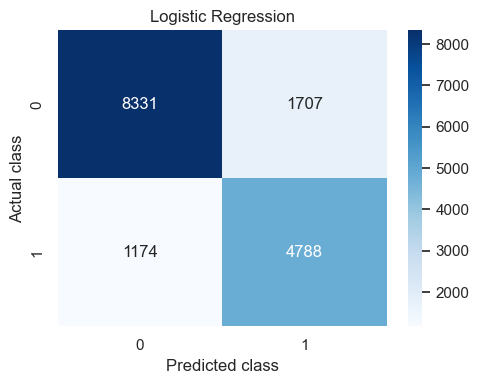

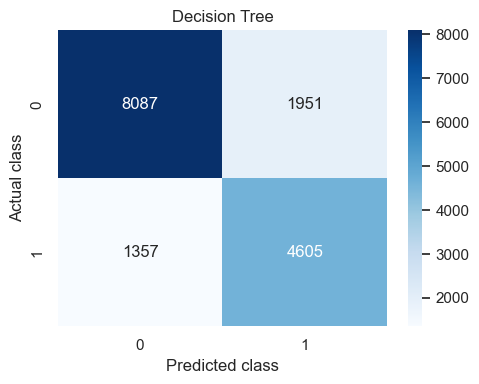

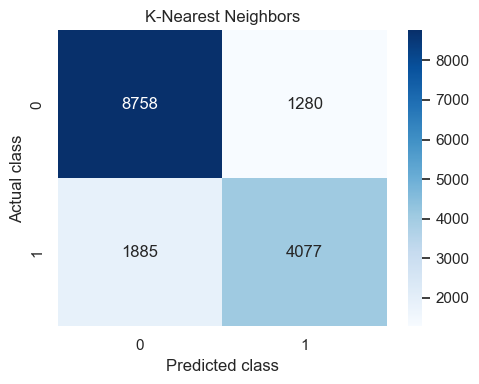

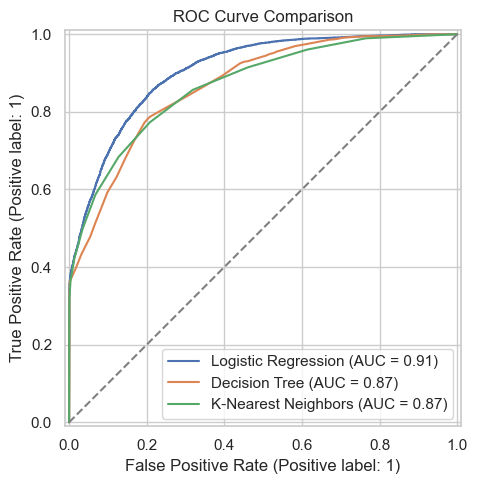

5-Fold cross-validation results
              model  accuracy  balanced_accuracy  precision  recall  f1_score  roc_auc
Logistic Regression    0.8199             0.8165     0.7374  0.8031    0.7687   0.9069
      Decision Tree    0.7932             0.7890     0.7026  0.7724    0.7357   0.8692
K-Nearest Neighbors    0.8022             0.7782     0.7614  0.6838    0.7204   0.8699

Best basic model based on training CV F1-score: Logistic Regression

Decision Tree feature importance
                    feature  importance
               deposit_type      0.4466
             market_segment      0.1942
                    country      0.0984
                  lead_time      0.0965
  total_of_special_requests      0.0841
required_car_parking_spaces      0.0453
     previous_cancellations      0.0255
                      agent      0.0064
                    company      0.0014
            booking_changes      0.0009


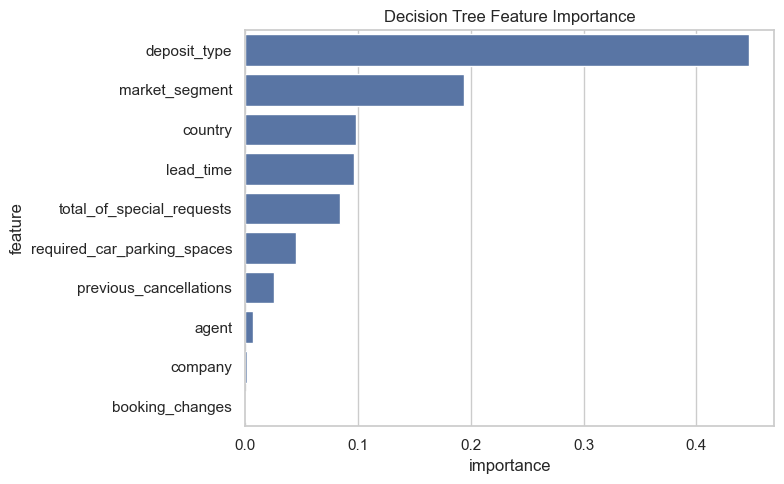

In [4]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


RANDOM_STATE = 42
df = take_stratified_sample(load_cleaned_data(), 20_000, RANDOM_STATE)
X = df.drop(columns="is_canceled")
y = df["is_canceled"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

categorical_columns = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()

# Scaling keeps distance-based KNN and coefficient-based models comparable.
preprocessor = ColumnTransformer(
    [
        (
            "numeric",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numerical_columns,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_columns,
        ),
    ]
)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=2000, solver="liblinear"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=11),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
roc_results = {}

for model_name, model in models.items():
    fold_results = []
    actual_values = []
    predicted_values = []
    probability_values = []

    for train_index, test_index in cv.split(X_train, y_train):
        pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
        pipeline.fit(X_train.iloc[train_index], y_train.iloc[train_index])
        prediction = pipeline.predict(X_train.iloc[test_index])
        probability = pipeline.predict_proba(X_train.iloc[test_index])[:, 1]
        actual = y_train.iloc[test_index]

        fold_results.append(
            {
                "accuracy": accuracy_score(actual, prediction),
                "balanced_accuracy": balanced_accuracy_score(actual, prediction),
                "precision": precision_score(actual, prediction, zero_division=0),
                "recall": recall_score(actual, prediction, zero_division=0),
                "f1_score": f1_score(actual, prediction, zero_division=0),
                "roc_auc": roc_auc_score(actual, probability),
            }
        )
        actual_values.extend(actual)
        predicted_values.extend(prediction)
        probability_values.extend(probability)

    mean_scores = pd.DataFrame(fold_results).mean()
    results.append({"model": model_name, **mean_scores.to_dict()})
    roc_results[model_name] = (actual_values, probability_values)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        confusion_matrix(actual_values, predicted_values),
        annot=True,
        fmt="d",
        cmap="Blues",
    )
    plt.title(model_name)
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for model_name, (actual, probability) in roc_results.items():
    RocCurveDisplay.from_predictions(actual, probability, name=model_name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve Comparison")
fig.tight_layout()
plt.show()

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
print("5-Fold cross-validation results")
print(results_df.round(4).to_string(index=False))
best_model_name = results_df.iloc[0]["model"]
print("\nBest basic model based on training CV F1-score:", best_model_name)

tree_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("model", models["Decision Tree"])]
)
tree_pipeline.fit(X_train, y_train)

feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": tree_pipeline.named_steps["model"].feature_importances_,
    }
)

for column in categorical_columns:
    importance_df.loc[
        importance_df["feature"].str.startswith(f"categorical__{column}_"),
        "feature",
    ] = column
importance_df["feature"] = importance_df["feature"].str.replace(
    "numeric__", "", regex=False
)
importance_df = (
    importance_df.groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nDecision Tree feature importance")
print(importance_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()


## 4. K-means Booking Segmentation

Cluster number evaluation
 number_of_clusters     inertia  silhouette_score  smallest_cluster_percentage
                  1 711384.0000               NaN                     100.0000
                  2 587550.1894            0.2309                      30.0361
                  3 498892.1984            0.2654                      13.3548
                  4 423318.8647            0.2395                      13.1861
                  5 370690.3352            0.2520                       1.1302
                  6 339546.9700            0.2630                       1.1285

Selected number of clusters: 3

Cluster summary
                     cluster_name  lead_time     adr  total_guests  total_stays  booking_changes  total_of_special_requests  family_booking_rate  cancellation_rate  booking_count  booking_percentage
cluster                                                                                                                                                                      

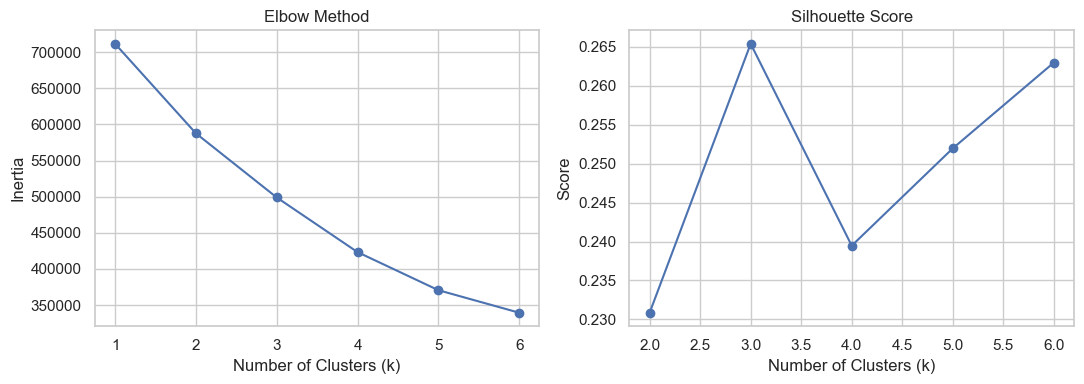

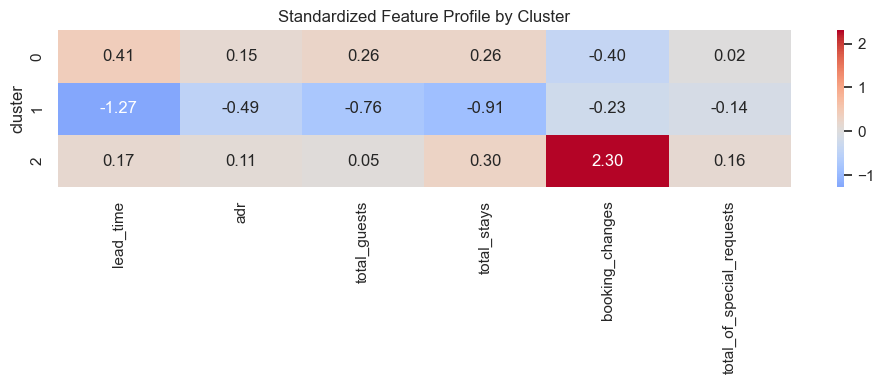

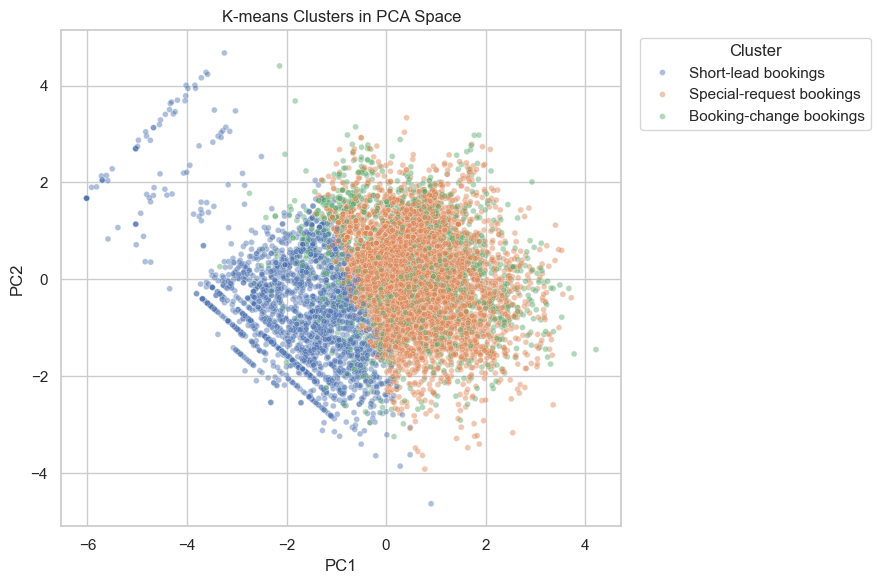

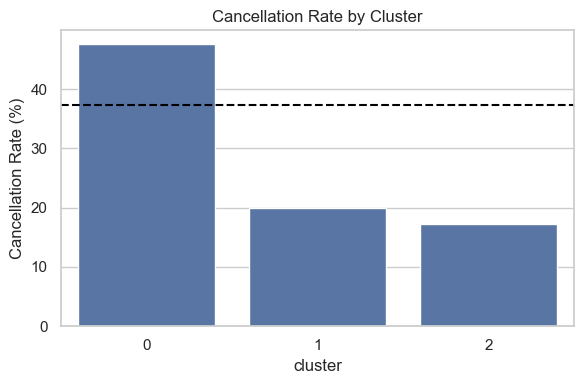

In [5]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42
df = load_cleaned_data()

cluster_features = [
    "lead_time",
    "adr",
    "total_guests",
    "total_stays",
    "booking_changes",
    "total_of_special_requests",
]

# K-means is suitable for scalable and interpretable numeric booking segments.
X_scaled = StandardScaler().fit_transform(np.log1p(df[cluster_features]))

evaluation_rows = []
for k in range(1, 7):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    evaluation_rows.append(
        {
            "number_of_clusters": k,
            "inertia": model.inertia_,
            "silhouette_score": (
                np.nan
                if k == 1
                else silhouette_score(
                    X_scaled, labels, sample_size=10_000, random_state=RANDOM_STATE
                )
            ),
            "smallest_cluster_percentage": (
                pd.Series(labels).value_counts(normalize=True).min() * 100
            ),
        }
    )

evaluation = pd.DataFrame(evaluation_rows)
candidates = evaluation[
    (evaluation["number_of_clusters"] >= 2)
    & (evaluation["smallest_cluster_percentage"] >= 10)
]
number_of_clusters = int(
    candidates.loc[candidates["silhouette_score"].idxmax(), "number_of_clusters"]
)

df["cluster"] = KMeans(
    n_clusters=number_of_clusters, random_state=RANDOM_STATE, n_init=10
).fit_predict(X_scaled)

cluster_summary = df.groupby("cluster")[
    cluster_features + ["is_family", "is_canceled"]
].mean()
cluster_summary = cluster_summary.rename(
    columns={"is_family": "family_booking_rate", "is_canceled": "cancellation_rate"}
)
cluster_summary["booking_count"] = df.groupby("cluster").size()
cluster_summary["booking_percentage"] = cluster_summary["booking_count"] / len(df) * 100
cluster_summary[["family_booking_rate", "cancellation_rate"]] *= 100

# Cluster labels are arbitrary, so names are assigned from observed profiles.
cluster_names = {}
unlabeled_clusters = set(cluster_summary.index)
naming_rules = [
    ("booking_changes", "idxmax", "Booking-change bookings"),
    ("total_of_special_requests", "idxmax", "Special-request bookings"),
    ("lead_time", "idxmin", "Short-lead bookings"),
    ("lead_time", "idxmax", "Long-lead bookings"),
]
for column, selector, name in naming_rules:
    if not unlabeled_clusters:
        break
    values = cluster_summary.loc[list(unlabeled_clusters), column]
    cluster = getattr(values, selector)()
    cluster_names[cluster] = name
    unlabeled_clusters.remove(cluster)

for cluster in unlabeled_clusters:
    cluster_names[cluster] = f"Booking segment {cluster}"

cluster_summary.insert(
    0,
    "cluster_name",
    [cluster_names[cluster] for cluster in cluster_summary.index],
)

print("Cluster number evaluation")
print(evaluation.round(4).to_string(index=False))
print("\nSelected number of clusters:", number_of_clusters)
print("\nCluster summary")
print(cluster_summary.round(2).to_string())
print("\nCluster interpretation")
for cluster, name in cluster_names.items():
    print(f"- Cluster {cluster}: {name}")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(evaluation["number_of_clusters"], evaluation["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[1].plot(
    evaluation["number_of_clusters"].iloc[1:],
    evaluation["silhouette_score"].iloc[1:],
    marker="o",
)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

scaled_profile = pd.DataFrame(X_scaled, columns=cluster_features)
scaled_profile["cluster"] = df["cluster"].to_numpy()
plt.figure(figsize=(10, 4))
sns.heatmap(
    scaled_profile.groupby("cluster").mean(),
    annot=True,
    center=0,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Standardized Feature Profile by Cluster")
plt.tight_layout()
plt.show()

pca_coordinates = PCA(n_components=2).fit_transform(X_scaled)
pca_plot = pd.DataFrame(pca_coordinates, columns=["PC1", "PC2"])
pca_plot["cluster"] = df["cluster"].to_numpy()
pca_plot["cluster_name"] = pca_plot["cluster"].map(cluster_names)
pca_plot = pca_plot.sample(n=min(10_000, len(pca_plot)), random_state=RANDOM_STATE)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    alpha=0.45,
    s=18,
)
plt.title("K-means Clusters in PCA Space")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=cluster_summary.reset_index(), x="cluster", y="cancellation_rate")
plt.axhline(df["is_canceled"].mean() * 100, color="black", linestyle="--")
plt.title("Cancellation Rate by Cluster")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()


## 5. Preprocessing and Model Parameter Comparison

In [6]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


def compare_booking_models(
    cleaned_data,
    target_column="is_canceled",
    sample_size=20_000,
    test_size=0.2,
    cv_splits=5,
    random_state=42,
):
    """Compare preprocessing and classification model combinations.

    The function samples a cleaned booking dataset, creates a stratified
    training/test split, evaluates preprocessing and model combinations using
    stratified k-fold cross-validation on the training set, and evaluates the
    selected best model on the untouched test set.

    Parameters
    ----------
    cleaned_data : pandas.DataFrame
        Cleaned booking dataset containing predictor columns and the binary
        target column. Outcome leakage columns must already be removed.
    target_column : str, default="is_canceled"
        Name of the classification target column.
    sample_size : int or None, default=20000
        Number of stratified records used for comparison. If ``None`` or
        greater than the dataset size, all available records are used.
    test_size : float, default=0.2
        Fraction of sampled records reserved for final test evaluation.
    cv_splits : int, default=5
        Number of stratified cross-validation folds applied to training data.
    random_state : int, default=42
        Random seed used for sampling, splitting, and tree models.

    Returns
    -------
    dict
        Results containing all cross-validation combinations, the five
        highest-ranked combinations, the selected combination, final test
        scores, and the fitted best pipeline.

    Examples
    --------
    >>> output = compare_booking_models(load_cleaned_data())
    >>> output["top_five"][["model", "f1_score"]]
    >>> output["test_scores"]["roc_auc"]
    """
    if target_column not in cleaned_data.columns:
        raise ValueError(f"Target column '{target_column}' is not in cleaned_data.")
    if not 0 < test_size < 1:
        raise ValueError("test_size must be a float between 0 and 1.")
    if cv_splits < 2:
        raise ValueError("cv_splits must be at least 2.")

    data = take_stratified_sample(cleaned_data, sample_size, random_state)
    X = data.drop(columns=target_column)
    y = data[target_column]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    categorical_columns = X_train.select_dtypes(
        include=["object", "string"]
    ).columns.tolist()
    numerical_columns = X_train.select_dtypes(include=["number"]).columns.tolist()

    scalers = {"StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler()}
    encoders = {
        "OneHotEncoder": OneHotEncoder(handle_unknown="ignore"),
        "OrdinalEncoder": OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1
        ),
    }
    models = [
        (
            "Logistic Regression",
            "C=0.1, class_weight=balanced",
            LogisticRegression(
                C=0.1, class_weight="balanced", solver="liblinear", max_iter=2000
            ),
        ),
        (
            "Logistic Regression",
            "C=1.0, class_weight=balanced",
            LogisticRegression(
                C=1.0, class_weight="balanced", solver="liblinear", max_iter=2000
            ),
        ),
        (
            "Decision Tree",
            "max_depth=3, class_weight=balanced",
            DecisionTreeClassifier(
                max_depth=3, class_weight="balanced", random_state=random_state
            ),
        ),
        (
            "Decision Tree",
            "max_depth=5, class_weight=balanced",
            DecisionTreeClassifier(
                max_depth=5, class_weight="balanced", random_state=random_state
            ),
        ),
        (
            "Decision Tree",
            "max_depth=8, class_weight=balanced",
            DecisionTreeClassifier(
                max_depth=8, class_weight="balanced", random_state=random_state
            ),
        ),
        ("K-Nearest Neighbors", "n_neighbors=5", KNeighborsClassifier(n_neighbors=5)),
        (
            "K-Nearest Neighbors",
            "n_neighbors=11",
            KNeighborsClassifier(n_neighbors=11),
        ),
        (
            "K-Nearest Neighbors",
            "n_neighbors=21",
            KNeighborsClassifier(n_neighbors=21),
        ),
    ]

    def make_pipeline(scaler, encoder, model):
        preprocessor = ColumnTransformer(
            [
                (
                    "numeric",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", clone(scaler)),
                        ]
                    ),
                    numerical_columns,
                ),
                (
                    "categorical",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("encoder", clone(encoder)),
                        ]
                    ),
                    categorical_columns,
                ),
            ]
        )
        return Pipeline([("preprocessor", preprocessor), ("model", clone(model))])

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    result_rows = []
    for scaler_name, scaler in scalers.items():
        for encoder_name, encoder in encoders.items():
            for model_name, parameters, model in models:
                fold_rows = []
                for train_index, validation_index in cv.split(X_train, y_train):
                    pipeline = make_pipeline(scaler, encoder, model)
                    pipeline.fit(X_train.iloc[train_index], y_train.iloc[train_index])
                    prediction = pipeline.predict(X_train.iloc[validation_index])
                    actual = y_train.iloc[validation_index]
                    fold_rows.append(
                        {
                            "accuracy": accuracy_score(actual, prediction),
                            "balanced_accuracy": balanced_accuracy_score(
                                actual, prediction
                            ),
                            "precision": precision_score(
                                actual, prediction, zero_division=0
                            ),
                            "recall": recall_score(actual, prediction, zero_division=0),
                            "f1_score": f1_score(actual, prediction, zero_division=0),
                        }
                    )

                mean_scores = pd.DataFrame(fold_rows).mean()
                result_rows.append(
                    {
                        "scaling": scaler_name,
                        "encoding": encoder_name,
                        "model": model_name,
                        "parameters": parameters,
                        **mean_scores.to_dict(),
                    }
                )

    all_results = (
        pd.DataFrame(result_rows)
        .sort_values(["f1_score", "balanced_accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    top_five = all_results.head(5).copy()
    selected_combination = all_results.iloc[0].copy()
    selected_model = next(
        model
        for model_name, parameters, model in models
        if model_name == selected_combination["model"]
        and parameters == selected_combination["parameters"]
    )
    best_model = make_pipeline(
        scalers[selected_combination["scaling"]],
        encoders[selected_combination["encoding"]],
        selected_model,
    )
    best_model.fit(X_train, y_train)
    test_prediction = best_model.predict(X_test)
    test_probability = best_model.predict_proba(X_test)[:, 1]
    test_scores = pd.Series(
        {
            "accuracy": accuracy_score(y_test, test_prediction),
            "balanced_accuracy": balanced_accuracy_score(y_test, test_prediction),
            "precision": precision_score(y_test, test_prediction, zero_division=0),
            "recall": recall_score(y_test, test_prediction, zero_division=0),
            "f1_score": f1_score(y_test, test_prediction, zero_division=0),
            "roc_auc": roc_auc_score(y_test, test_probability),
        }
    )

    return {
        "all_results": all_results,
        "top_five": top_five,
        "selected_combination": selected_combination,
        "test_scores": test_scores,
        "best_model": best_model,
    }


output = compare_booking_models(load_cleaned_data())
selected = output["selected_combination"]

print("Top five combinations based on training CV F1-score")
print(output["top_five"].round(4).to_string(index=False))
print("\nFinal selected combination")
print(selected[["scaling", "encoding", "model", "parameters"]].to_string())
print("\nFinal test set results")
print(output["test_scores"].round(4).to_string())


Top five combinations based on training CV F1-score
       scaling      encoding               model                         parameters  accuracy  balanced_accuracy  precision  recall  f1_score
StandardScaler OneHotEncoder Logistic Regression       C=1.0, class_weight=balanced    0.8199             0.8165     0.7374  0.8031    0.7687
StandardScaler OneHotEncoder Logistic Regression       C=0.1, class_weight=balanced    0.8184             0.8150     0.7352  0.8016    0.7669
StandardScaler OneHotEncoder       Decision Tree max_depth=8, class_weight=balanced    0.8215             0.8134     0.7511  0.7815    0.7653
  MinMaxScaler OneHotEncoder       Decision Tree max_depth=8, class_weight=balanced    0.8214             0.8133     0.7509  0.7815    0.7652
  MinMaxScaler OneHotEncoder Logistic Regression       C=1.0, class_weight=balanced    0.8128             0.8098     0.7269  0.7981    0.7606

Final selected combination
scaling                     StandardScaler
encoding                 

### Sample Size Validation 

In [7]:
# Additional analysis: compare sampled versus full training stability on the same evaluation set.
full_validation_data = load_cleaned_data()
X_full = full_validation_data.drop(columns="is_canceled")
y_full = full_validation_data["is_canceled"]
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

full_training_data = pd.concat(
    [X_train_full, y_train_full.rename("is_canceled")], axis=1
)
sample_training_data, _ = train_test_split(
    full_training_data,
    train_size=20_000,
    stratify=full_training_data["is_canceled"],
    random_state=42,
)

validation_rows = []
for training_data_name, training_data in [
    ("20,000 training rows", sample_training_data),
    ("Full training rows", full_training_data),
]:
    # Refit a fresh copy of the selected model on each training set.
    final_model = clone(output["best_model"])
    final_model.fit(
        training_data.drop(columns="is_canceled"),
        training_data["is_canceled"],
    )
    prediction = final_model.predict(X_test_full)
    probability = final_model.predict_proba(X_test_full)[:, 1]
    validation_rows.append(
        {
            "training_data": training_data_name,
            "training_rows": len(training_data),
            "same_test_rows": len(X_test_full),
            "accuracy": accuracy_score(y_test_full, prediction),
            "balanced_accuracy": balanced_accuracy_score(y_test_full, prediction),
            "precision": precision_score(y_test_full, prediction, zero_division=0),
            "recall": recall_score(y_test_full, prediction, zero_division=0),
            "f1_score": f1_score(y_test_full, prediction, zero_division=0),
            "roc_auc": roc_auc_score(y_test_full, probability),
        }
    )

full_data_validation = pd.DataFrame(validation_rows).set_index("training_data")
difference = full_data_validation.loc["Full training rows"] - full_data_validation.loc[
    "20,000 training rows"
]

print("Sample-versus-full training stability check for the selected final model on the same evaluation set")
print("Selected model:", selected["model"], "-", selected["parameters"])
print(full_data_validation.round(4).to_string())
print("\nFull training rows minus 20,000 training rows")
print(
    difference[["accuracy", "precision", "recall", "f1_score", "roc_auc"]]
    .round(4)
    .to_string()
)


Sample-versus-full training stability check for the selected final model on the same evaluation set
Selected model: Logistic Regression - C=1.0, class_weight=balanced
                      training_rows  same_test_rows  accuracy  balanced_accuracy  precision  recall  f1_score  roc_auc
training_data                                                                                                         
20,000 training rows          20000           23713    0.8197             0.8174     0.7343  0.8086    0.7697   0.9076
Full training rows            94851           23713    0.8216             0.8193     0.7370  0.8102    0.7719   0.9098

Full training rows minus 20,000 training rows
accuracy     0.0019
precision    0.0027
recall       0.0016
f1_score     0.0022
roc_auc      0.0021
